In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from glob import glob

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
DATA_DIR = "../data/raw/Motorbikes"
IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_CHANNELS = 3
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 32

image_paths = glob(os.path.join(DATA_DIR, "*.jpg"))
print(f"Found {len(image_paths)} images in {DATA_DIR}")

# Calculate split sizes
total_images = len(image_paths)
val_size = int(total_images * VALIDATION_SPLIT)
train_size = total_images - val_size

print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")

Found 211 images in ../data/raw/Motorbikes
Training samples: 169
Validation samples: 42


In [5]:
# Function to load and preprocess images
def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0
    return img, img

In [6]:
dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.shuffle(buffer_size=len(image_paths), seed=42)
dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)
train_generator = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_generator = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Batch shape: (32, 64, 64, 3)
Pixel value range: [0.000, 1.000]


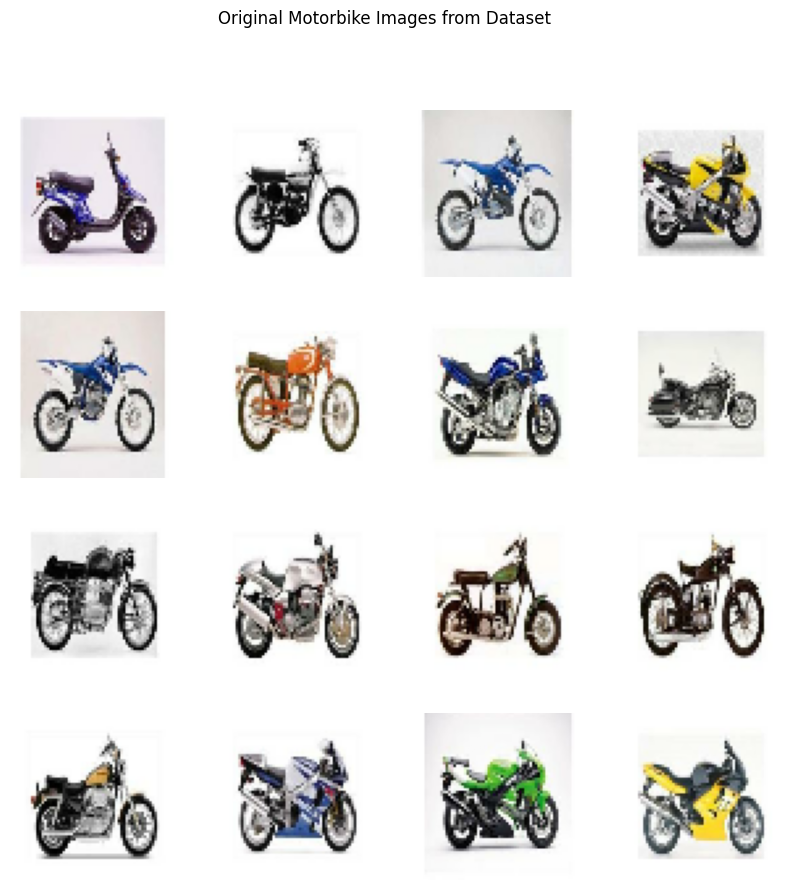

In [7]:
# Utility function to plot images
def plot_images(images, title="Sample Images"):
    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

for batch in train_generator.take(1):
    sample_images = batch[0].numpy()
    break

print(f"Batch shape: {sample_images.shape}")
print(f"Pixel value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")

# Display first 16 images
plot_images(sample_images[:16], title="Original Motorbike Images from Dataset")